# Practice Dataset Statistics

Notebook này chỉ tập trung vào `Practice_Dataset` vì đây là phần có đủ ground truth driver để:

- thống kê phân bố label
- xem phân bố theo trip và theo subject
- phân tích alertness, transition và segment
- chuẩn bị training index / grouped validation về sau

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    if (PROJECT_ROOT.parent / "AGENTS.md").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise FileNotFoundError("Cannot locate project root from the current notebook working directory.")

NOTEBOOK_HELPERS = PROJECT_ROOT / "notebooks"
if str(NOTEBOOK_HELPERS) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_HELPERS))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import fleetiq_notebook_utils as nb

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
practice_df = nb.build_practice_frame_index()
practice_df.head()

,trip_id,dataset_name,frame_id,world_frame,timestamp,speed_kmh,longitudinal_accel,lateral_accel,driver_state,alertness_score,eye_state,head_pose,mouth_state,subject_id,min_ttc,headway_sec,base_risk,driver_factor,final_risk_score,is_harsh_brake,is_harsh_accel,is_harsh_corner,is_speeding,is_tailgating,target_count,target_classes,target_ids_sample,target_min_ttc_2d,target_min_longitudinal_distance,events_active_count,events_active_types,has_left_image,has_right_image,has_driver_image,has_depth,has_calib,has_label,dt,event_t,last_event_type
0,T01-Sample,practice,0,96263,0.00,0.00,0.0,0.0,distracted,0.45,open,side,normal,14,inf,inf,0.0,2.2,0.0,False,False,False,False,False,11,vehicle,290|291|292|294|301,inf,0.701,0,,True,True,True,True,True,True,NaN,NaN,NaN
1,T01-Sample,practice,1,96264,0.05,7.82,0.0,0.0,distracted,0.45,open,side,normal,14,inf,inf,0.0,2.2,0.0,False,False,False,False,False,11,vehicle,290|291|292|294|301,inf,0.703,0,,True,True,True,False,True,True,0.05,NaN,NaN
2,T01-Sample,practice,2,96265,0.10,4.53,0.0,0.0,distracted,0.45,open,side,normal,14,inf,inf,0.0,2.2,0.0,False,False,False,False,False,11,vehicle,290|291|292|294|301,inf,0.705,0,,True,True,True,False,True,True,0.05,NaN,NaN
3,T01-Sample,practice,3,96266,0.15,1.66,0.0,0.0,distracted,0.45,open,side,normal,14,inf,inf,0.0,2.2,0.0,False,False,False,False,False,11,vehicle,290|291|292|294|301,inf,0.707,0,,True,True,True,False,True,True,0.05,NaN,NaN
4,T01-Sample,practice,4,96267,0.20,0.29,0.0,0.0,distracted,0.45,open,side,normal,14,inf,inf,0.0,2.2,0.0,False,False,False,False,False,11,vehicle,290|291|292|294|301,inf,0.709,0,,True,True,True,False,True,True,0.05,NaN,NaN


In [3]:
dist = nb.state_distribution_tables(practice_df)
dist["overall"]

,driver_state,frame_count,ratio
1,distracted,900,0.250000
2,drowsy,900,0.250000
0,alert,600,0.166667
3,microsleep,600,0.166667
4,yawning,600,0.166667


In [4]:
dist["by_trip"]

driver_state,trip_id,alert,distracted,drowsy,microsleep,yawning
0,T01-Sample,300,300,0,0,0
1,T02-Sample,0,0,600,0,0
2,T03-Sample,0,0,0,0,600
3,T04-Sample,300,300,0,0,0
4,T05-Sample,0,0,0,600,0
5,T06-Sample,0,300,300,0,0


In [5]:
dist["by_subject"]

driver_state,subject_id,alert,distracted,drowsy,microsleep,yawning
0,1,0,0,0,0,600
1,10,0,0,600,0,0
2,14,300,300,0,0,0
3,23,0,300,300,0,0
4,36,0,0,0,600,0
5,6,300,300,0,0,0


In [6]:
alertness_stats = (
    practice_df.groupby("driver_state")["alertness_score"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .sort_values("mean")
)
alertness_stats

,count,mean,std,min,median,max
driver_state,,,,,,
microsleep,600,0.05,0.0,0.05,0.05,0.05
drowsy,900,0.35,0.0,0.35,0.35,0.35
distracted,900,0.45,0.0,0.45,0.45,0.45
yawning,600,0.55,0.0,0.55,0.55,0.55
alert,600,0.95,0.0,0.95,0.95,0.95


In [7]:
transition_matrix = nb.compute_state_transitions(practice_df)
transition_pivot = transition_matrix.pivot(
    index="driver_state",
    columns="next_state",
    values="count",
).fillna(0).astype(int)
transition_pivot

next_state,alert,distracted,drowsy,microsleep,yawning
driver_state,,,,,
alert,598,0,0,0,0
distracted,2,897,0,0,0
drowsy,0,1,898,0,0
microsleep,0,0,0,599,0
yawning,0,0,0,0,599


In [8]:
trip_id = "T01-Sample"
trip_df = practice_df.query("trip_id == @trip_id").copy()
segments = nb.derive_state_segments(trip_df)
segments

,trip_id,segment_id,driver_state,start_frame,end_frame,start_ts,end_ts,frame_count,min_alertness,mean_speed_kmh,duration_sec
0,T01-Sample,1,distracted,0,299,0.0,14.95,300,0.45,27.087367,15.0
1,T01-Sample,2,alert,300,599,15.0,29.95,300,0.95,23.557500,15.0


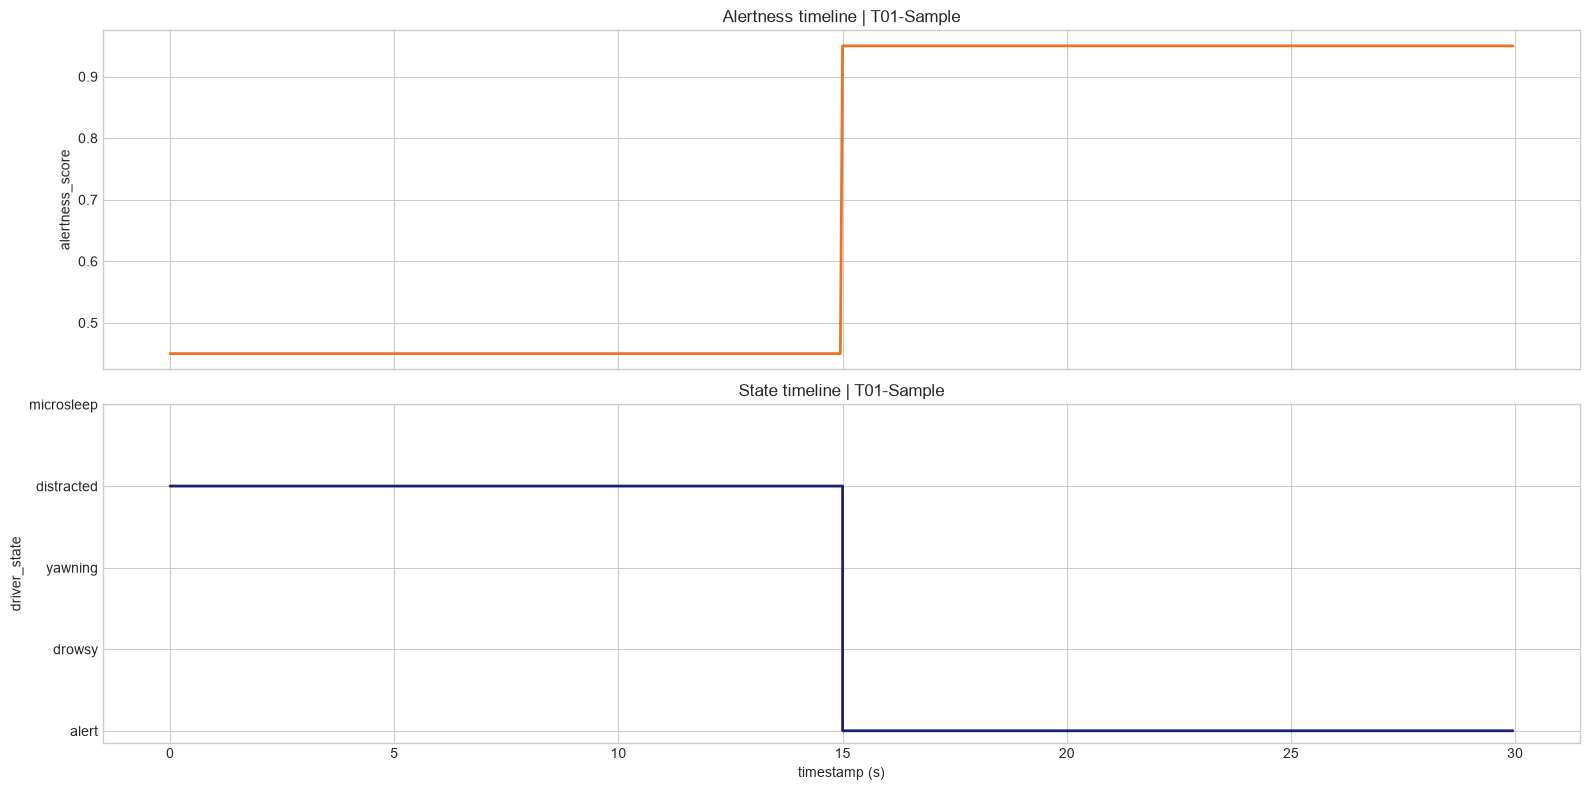

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

state_order = ["alert", "drowsy", "yawning", "distracted", "microsleep"]
state_map = {state: idx for idx, state in enumerate(state_order)}

axes[0].plot(trip_df["timestamp"], trip_df["alertness_score"], color="#F37021", linewidth=2)
axes[0].set_ylabel("alertness_score")
axes[0].set_title(f"Alertness timeline | {trip_id}")

axes[1].step(
    trip_df["timestamp"],
    trip_df["driver_state"].map(state_map),
    where="post",
    color="#19226D",
    linewidth=2,
)
axes[1].set_yticks(list(state_map.values()))
axes[1].set_yticklabels(state_order)
axes[1].set_ylabel("driver_state")
axes[1].set_xlabel("timestamp (s)")
axes[1].set_title(f"State timeline | {trip_id}")

plt.tight_layout()

In [10]:
out_dir = PROJECT_ROOT / "artifacts" / "practice_stats"
out_dir.mkdir(parents=True, exist_ok=True)
practice_df.to_csv(out_dir / "practice_frame_index.csv", index=False)
segments.to_csv(out_dir / f"{trip_id}_segments.csv", index=False)
alertness_stats.to_csv(out_dir / "alertness_stats.csv")
out_dir

WindowsPath('C:/Users/admin/Documents/Projects/AutomotiveHacathon/artifacts/practice_stats')